In [1]:
import pandas as pd
asbestos = pd.read_csv("Asbestos-Permits.csv")
sales = pd.read_csv("Estate-Sales.csv")
properties = pd.read_csv("Condemned-Properties.csv")

Dataset 1 intro (Condemned-Properties)

neighborhood
Arlington Heights            2
North Oakland                2
Central Business District    1
Chateau                      1
South Shore                  1
Duquesne Heights             1
Strip District               1
Friendship                   1
Allegheny West               1
Central Oakland              1
Name: count, dtype: int64

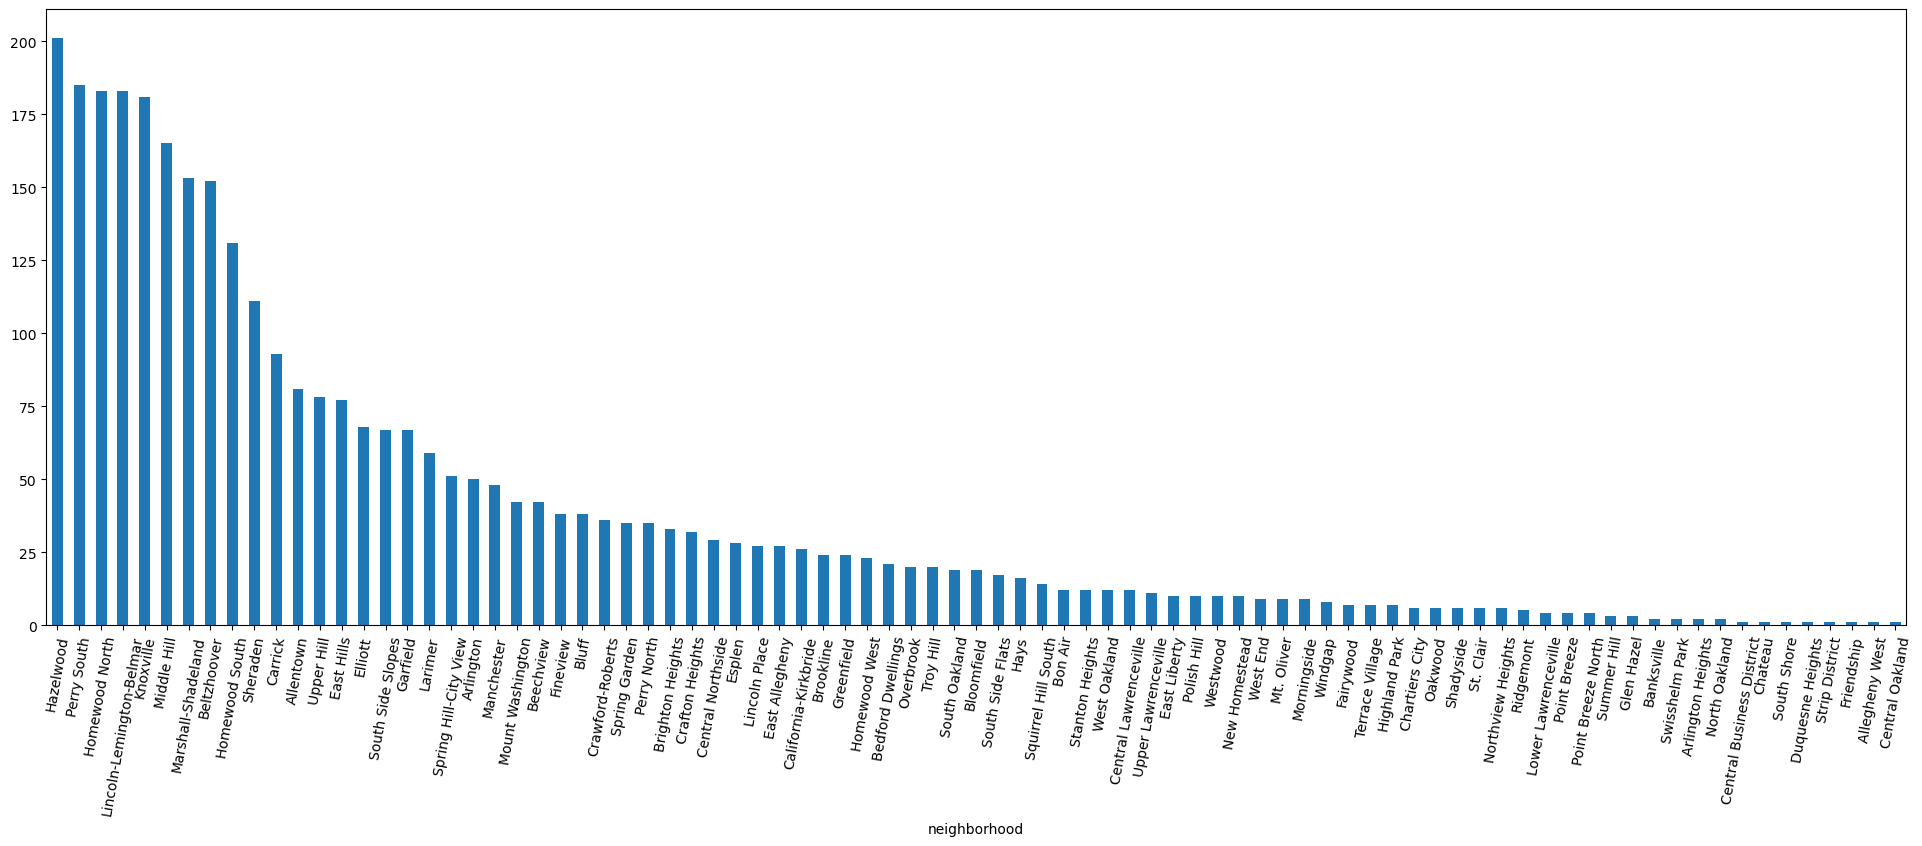

In [2]:
prop_counts=properties['neighborhood'].value_counts()
prop_counts.plot(kind='bar',figsize=(24,8),rot=80)
low_condemnation_neighborhoods=prop_counts.tail(10)
low_condemnation_neighborhoods.head(10)

<Axes: >

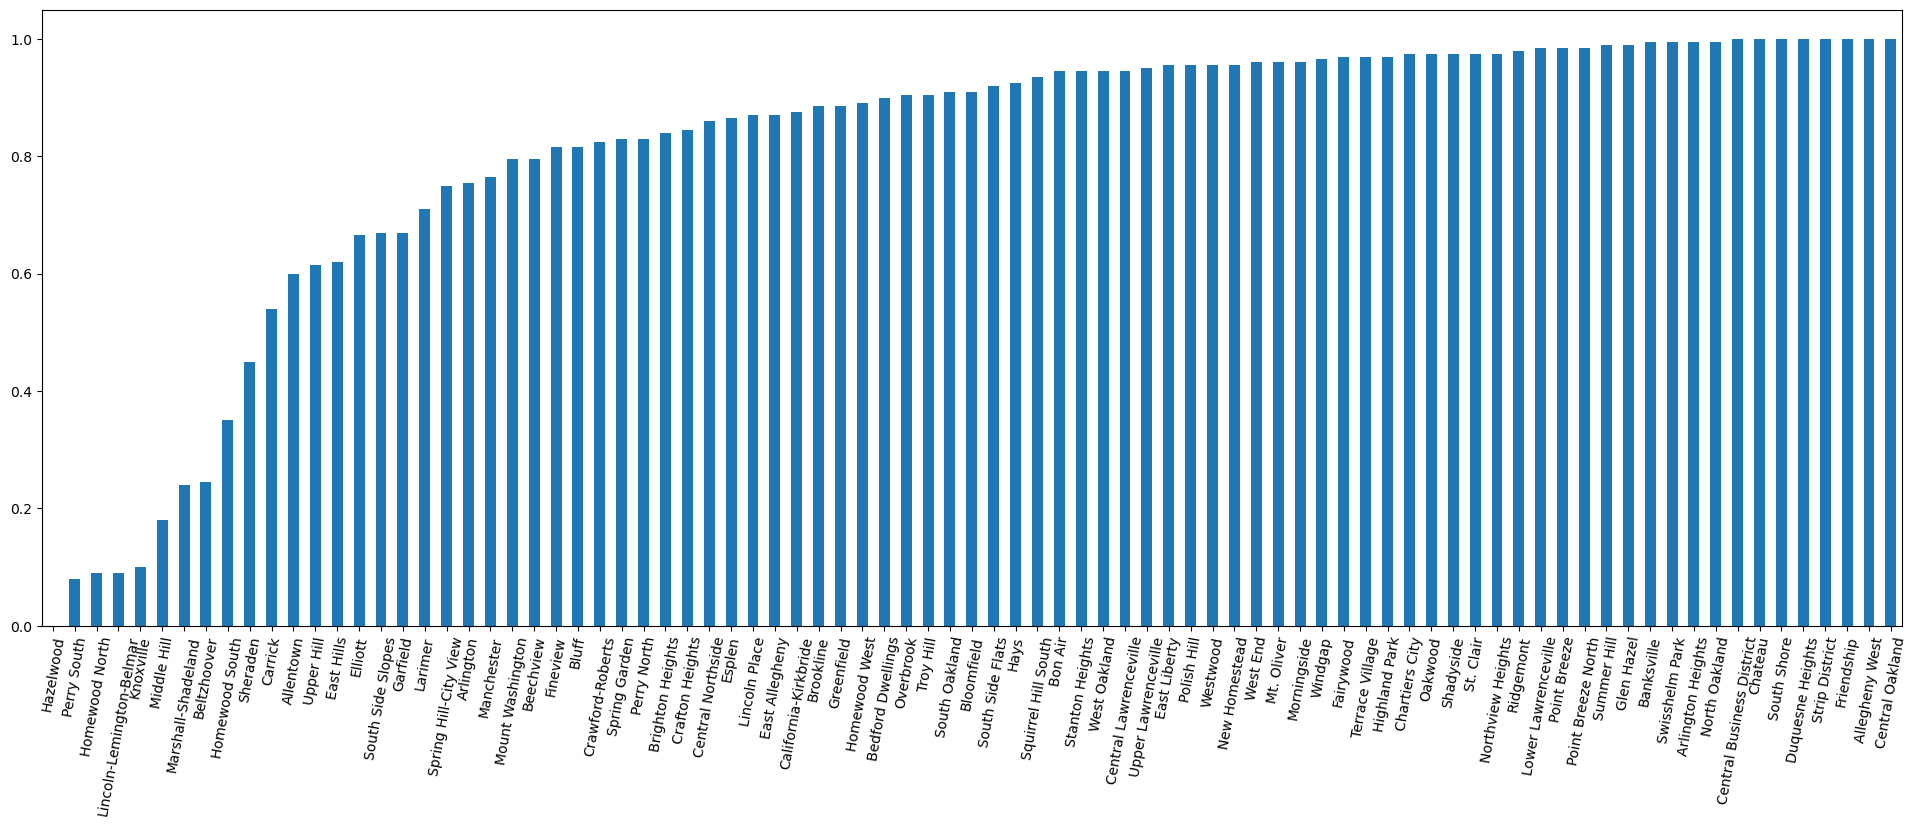

In [3]:
range=prop_counts.max()-prop_counts.min()
min=prop_counts.min()
prop_scores=pd.Series()
for prop, value in prop_counts.items():
    prop_scores.at[prop]=1-(value-min)/range
prop_scores.tail(10)
prop_scores.plot(kind='bar',figsize=(24,8),rot=80)

Dataset 1 analysis

Dataset 2 intro (Estate-Sales)

In [4]:
import geopandas
from shapely.geometry import Point
ZIPS = geopandas.read_file("https://data.wprdc.org/dataset/1a5135de-cabe-4e23-b5e4-b2b8dd733817/resource/ec228c0e-6b1e-4f44-a335-df05546d52ea/download/alcogisallegheny-county-zip-code-boundaries.zip")
NEIGHBORHOODS = geopandas.read_file("https://data.wprdc.org/dataset/e672f13d-71c4-4a66-8f38-710e75ed80a4/resource/c5a93a8e-03d7-4eb3-91a8-c6b7db0fa261/download/pittsburghpaneighborhoods-.zip").to_crs(ZIPS.crs)

def zip_to_neighborhoods(zip_code):
    """Converts a ZIP code to a list of Pittsburgh neighborhood names.

    Args:
        zip_code (int): The ZIP code of interest.

    Returns:
        list[str]: A list of neighborhood names within that ZIP code.
    """
    # Get this specific zip
    zips_filtered = ZIPS[ZIPS["ZIP"] == str(zip_code)]
    if len(zips_filtered) < 1:
        return None
    zp = zips_filtered.iloc[0]
    # List of neighborhoods for this zip
    zp_neighborhoods = []
    # Loop through the neighborhoods
    for _idx, neighborhood in NEIGHBORHOODS.iterrows():
        # Check if this zip intersects the neighborhood
        if neighborhood["geometry"].intersects(zp["geometry"]):
            # Add this neighborhood to the list
            zp_neighborhoods.append(neighborhood["hood"])
    return zp_neighborhoods





<Axes: xlabel='Neighborhoods'>

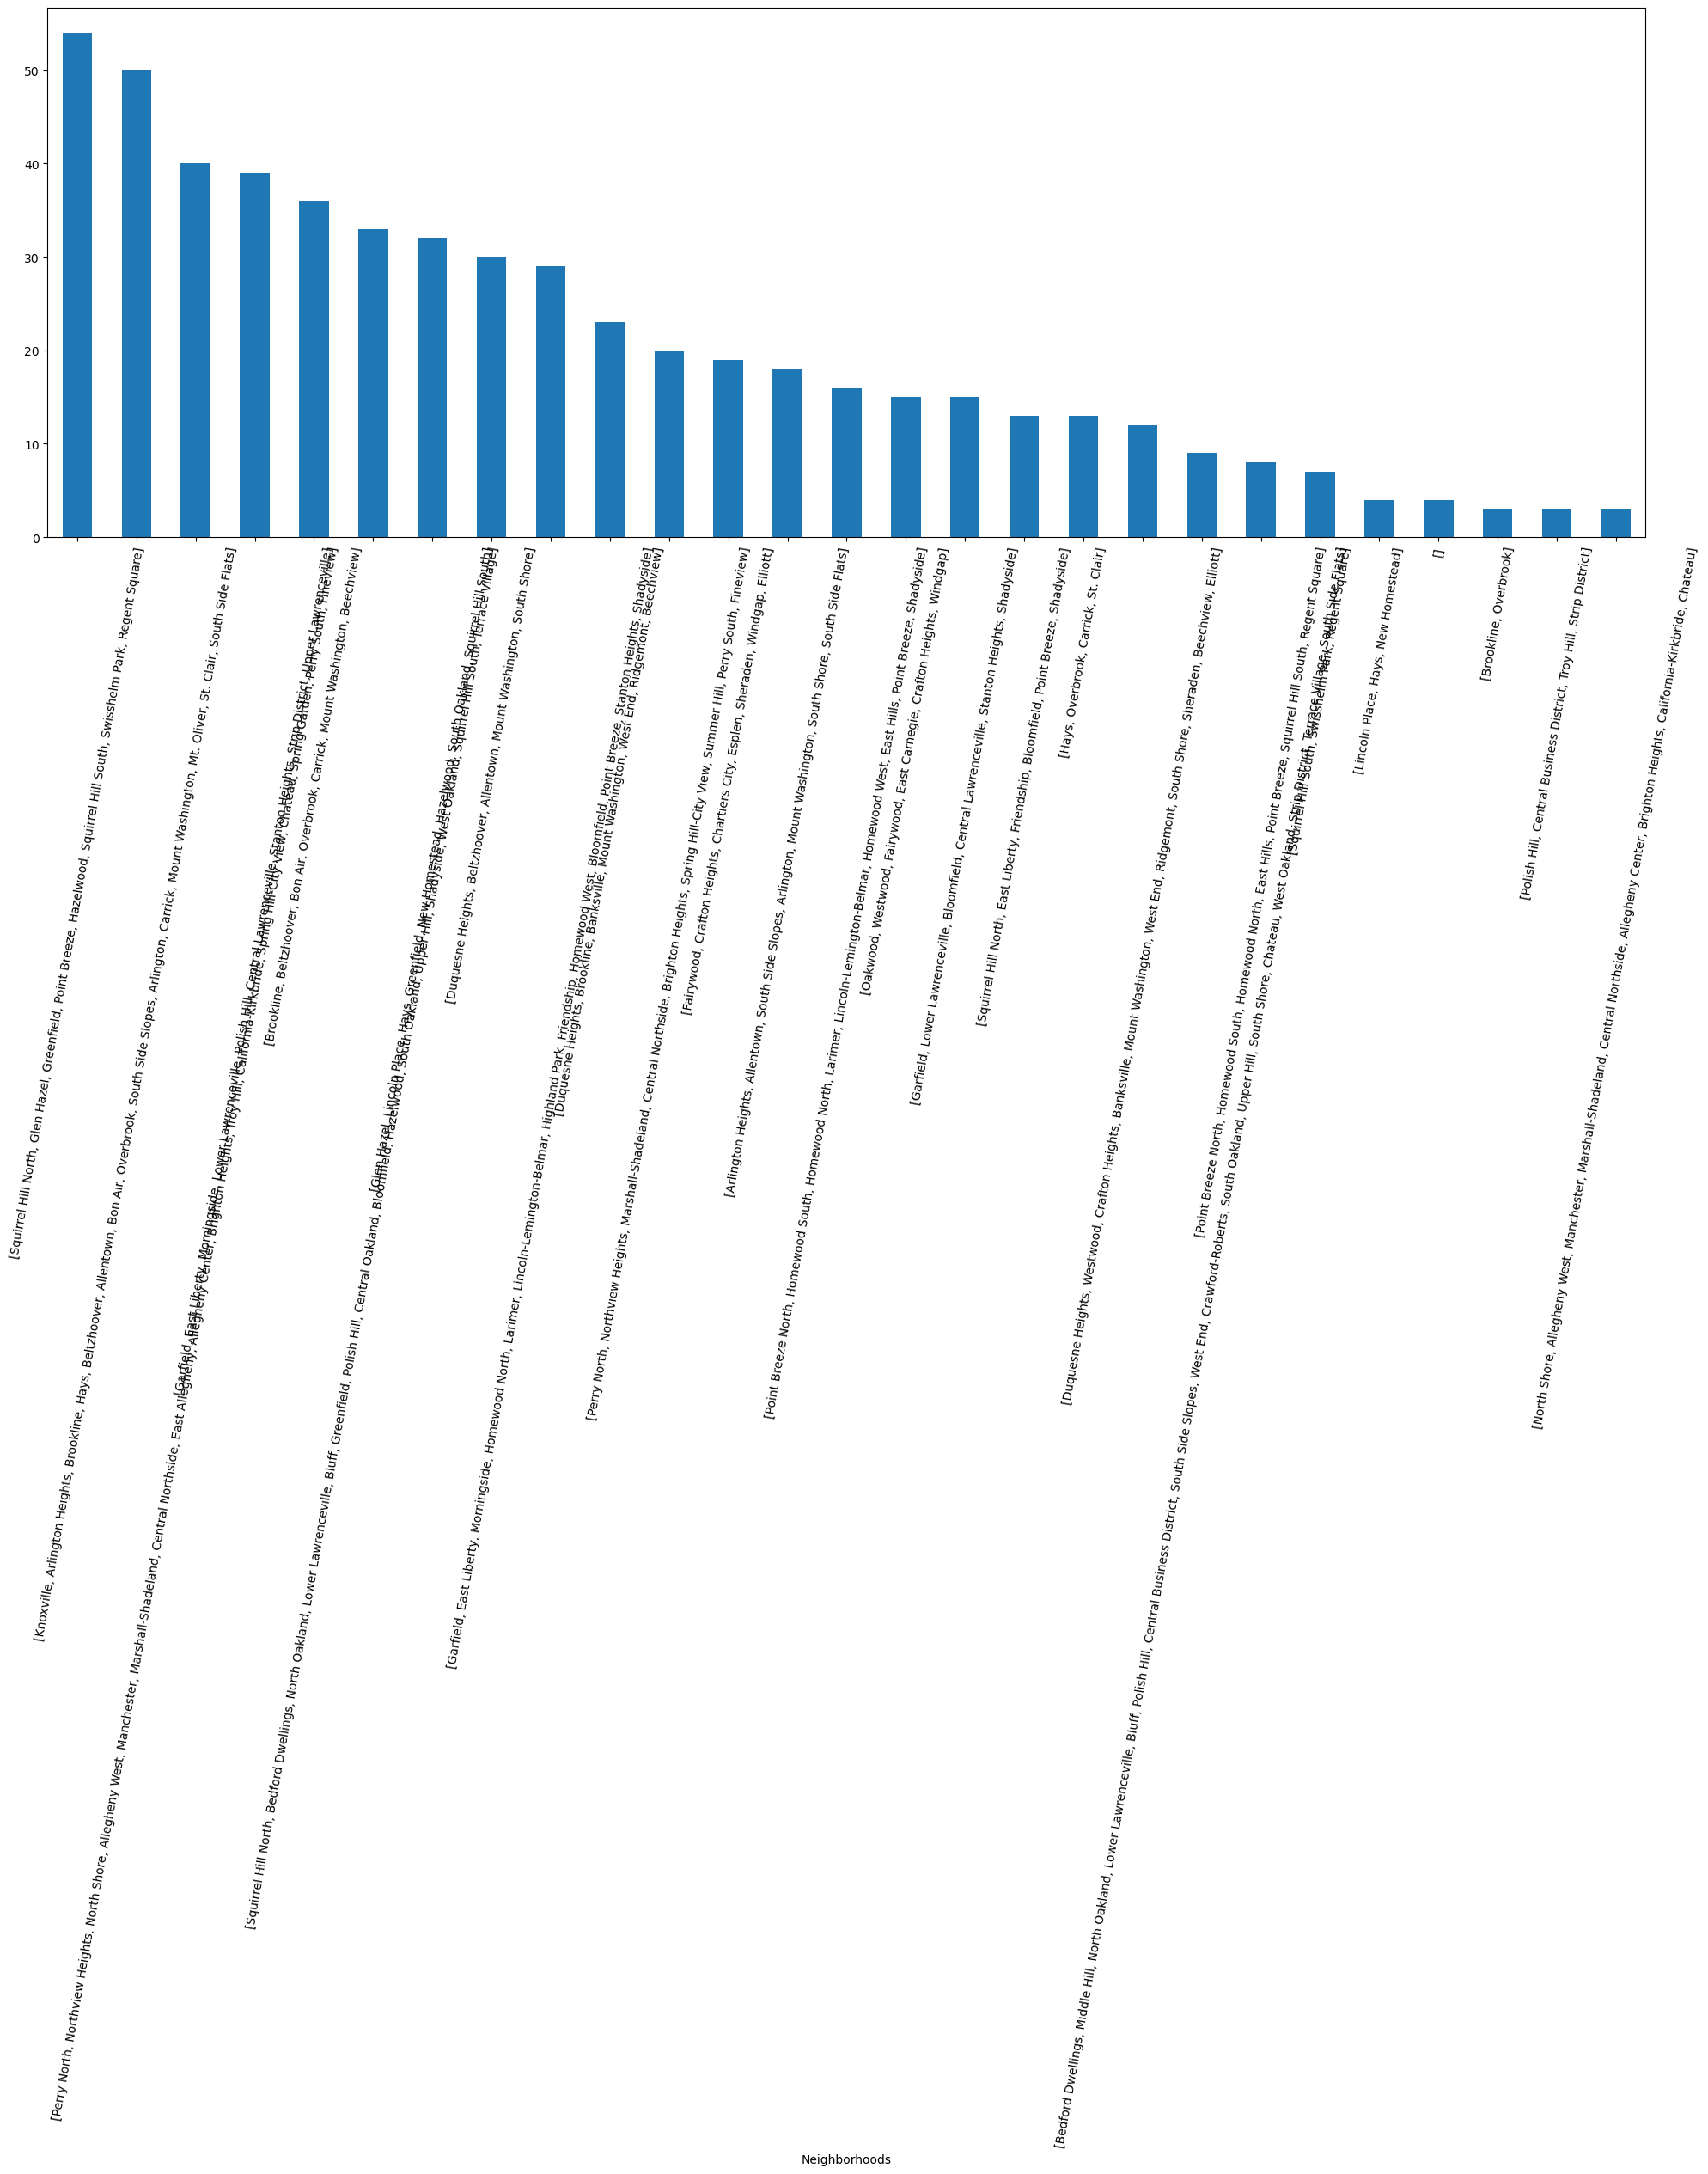

In [5]:
sales["Neighborhoods"] = sales["PROPERTYZIP"].astype(str).apply(zip_to_neighborhoods)
sales_counts = sales["Neighborhoods"].value_counts()
sales_counts.plot(kind = "bar", figsize = (24,8),rot = 80)

In [6]:
average_sale = sales.groupby("Neighborhoods")["PRICE"].mean()
average_sale.plot(kind = "bar", figsize = (24,8),rot = 80)

TypeError: unhashable type: 'list'

In [ ]:
top10avgsale = average_sale.sort_values(ascending = False).head(20)
print(top10avgsale)

In [ ]:
highest_avg_sale = average_sale.sort_values(ascending = False)
highest_avg_sale.sort_values(ascending = False) 
max_value = highest_avg_sale.iloc[0] 
min_value = highest_avg_sale.iloc[len(highest_avg_sale) - 1] 
score = (highest_avg_sale - min_value)/ (max_value - min_value) 
print(score)

Dataset 2 analysis

Dataset 3 intro (Asbestos)

In [ ]:
import geopandas
import pandas
from shapely.geometry import Point

# Load zip codes
ZIPS = geopandas.read_file("https://data.wprdc.org/dataset/1a5135de-cabe-4e23-b5e4-b2b8dd733817/resource/ec228c0e-6b1e-4f44-a335-df05546d52ea/download/alcogisallegheny-county-zip-code-boundaries.zip")

# Load neighborhoods and use zip codes to convert
NEIGHBORHOODS = geopandas.read_file("https://data.wprdc.org/dataset/e672f13d-71c4-4a66-8f38-710e75ed80a4/resource/c5a93a8e-03d7-4eb3-91a8-c6b7db0fa261/download/pittsburghpaneighborhoods-.zip").to_crs(ZIPS.crs)

def geo_to_neighborhood(latitude, longitude):
    """Converts a geolocation (latitude and longitude) to a Pittsburgh neighborhood name.

    Args:
        latitude (float): The latitude of the point.
        longitude (float): The longitude of the point.

    Returns:
        Union[str, None]: Name of the Pittsburgh neighborhood the point falls within or None if it does not fall within a neighborhood.
    """
    # Create a shapely point for the latitude and longitude
    pt = Point(longitude, latitude)
    # Loop through the neighborhoods
    for _idx, neighborhood in NEIGHBORHOODS.iterrows():
        # Check if this neighborhood contains the point
        if neighborhood["geometry"].contains(pt):
            # Return the name of the neighborhood
            return neighborhood["hood"]
    # Wasn't contained in the neighborhood
    return None

def zip_to_neighborhoods(zip_code):
    """Converts a ZIP code to a list of Pittsburgh neighborhood names.

    Args:
        zip_code (int): The ZIP code of interest.

    Returns:
        list[str]: A list of neighborhood names within that ZIP code.
    """
    # Get this specific zip
    zips_filtered = ZIPS[ZIPS["ZIP"] == str(zip_code)]
    if len(zips_filtered) < 1:
        return None
    zp = zips_filtered.iloc[0]
    # List of neighborhoods for this zip
    zp_neighborhoods = []
    # Loop through the neighborhoods
    for _idx, neighborhood in NEIGHBORHOODS.iterrows():
        # Check if this zip intersects the neighborhood
        if neighborhood["geometry"].intersects(zp["geometry"]):
            # Add this neighborhood to the list
            zp_neighborhoods.append(neighborhood["hood"])
    return zp_neighborhoods

# def census_to_neighborhoods(census_tract):
#     """Converts a census tract number to a list of Pittsburgh neighborhoods.

#     Args:
#         census_tract (int): The Census tract of interest.

#     Returns:
#         list[str]: A list of Pittsburgh neighborhood names that
#     """
#     # Census to ZIP data
#     census_data = pandas.read_csv("./ZIP_TRACT_032020.csv")
#     tract_filtered = census_data[census_data["TRACT"] == census_tract]
#     if len(tract_filtered) < 1:
#         return []
#     tract = tract_filtered.iloc[0]
#     return zip_to_neighborhoods(int(tract["ZIP"]))

In [ ]:
mask = asbestos["city"] == "PITTSBURGH"
hasAsbestos = asbestos["p_fee"] > 0
asbestosProperties = asbestos[mask & hasAsbestos]
asbestosProperties["Neighbourhoods"] = asbestosProperties["z_code"].astype(str).apply(zip_to_neighborhoods)
asbestosProperties = asbestosProperties.explode("Neighbourhoods")
asbestosCounts = asbestosProperties["Neighbourhoods"].value_counts()
asbestosCounts.plot(kind = "bar", figsize = (24,8),rot = 80)


In [ ]:
for num in asbestosProperties['_id']:
    print(num)

Dataset 3 analysis

Final analysis intro

In [ ]:
#weighting of 3 metrics

Conclusion